# CRE III - Assignment 1 - Parameter Estimation

by group 7: \
Peter Schönung (1144689)\
Taha Sekerci (3069213)\
Kavya Valluru (3070479)

# 1. Introduction

In chemical reaction engineering, parameter estimation is an important technique used to determine reaction parameters from experimental data when they are not fully known. This is often the case when we explore novel chemical processes or complex reaction networks. In these cases, the reaction parameters and mechanisms are partially or even fully unknown. Determining suitable values for these is an important task, which requires the combination of high knowledge about chemical reactions and a rigorous methodology. Computational parameter estimation enables us to obtain mathematically sound estimates for these parameters, given that we can lay a sound theoretical foundation for the underlying reaction(s).

This report focuses on a constant volume batch reactor system involving the species A, B, C, D, E and F, for which the concentration–time data of 6 experiments were given. Our task is to analyze this unidentified reaction network, and estimate fitting reaction parameters for it.

To do that, we are going to analyze the given data, formulate possible reactions for each species and hypothesize a reaction network for all species combined. For this reaction network, we will use computational estimation methods from the python package `lmfit` to fit reaction parameters in such a way, that the simulated reaction network reproduces the experimental results as close as possible. For this estimation, it is important to check that the error between the simulated and experimental data is sufficiently small to draw reliable conclusions about the reaction parameters. Also, we need to check the resulting (fitted) parameters for reasonable values, as we don't only want a mathematically accurate but also a physically realistic model describing the experimental data.

For the parameters to be estimated, we will first concentrate on the kinetic parameters k of the reactions. These kinetic parameters are important for the reaction networks as they quantify reaction rates and describe their dynamic behavior [1] and varying them tells how strong the reaction network changes in mechanism, uncertainty, and operating conditions.[2,3] Secondly we will also fit the reaction orders n of the reactions, to produce an even better fit.

This sequential strategy — estimating k before n — is mathematically justified because the rate law $ r = k c^n$ is linear in k but highly nonlinear in n. Fitting k with fixed n yields a well-posed linear regression problem, whereas fitting n first creates a severely ill-posed optimization problem with multiple local minima. This sequential approach converts the problem into a tractable parameter estimation task.

# 2. Batch Reactor Basics

The presented system is a constant volume batch reactor, in which a single phase contains up to 6 species. We assume isothermal conditions, which in combination with the constant volume simplifies the general mass balance for a species to: [1]

\begin{equation}
    \frac{\partial c_{i}}{\partial t} = \sum_j{\nu_{i,j}\, r_j} \tag{1}
\end{equation}

Here, $r_j$ is the reaction rate of reaction j, $\nu_{i,j}$ is the stochiometric coefficient of the species i for reaction j

The kinetic rate expression for a reaction is used to describe the reaction mechanism. It describes the speed at which a reaction takes place, and allows the rate of change of each component to be determined. The form of the kinetic rate expression depends on the type of underlying reaction [1]. A rate expression for a combination reaction such as $A + B \rightarrow C$ would look like:

\begin{equation}
   r_j = k_j \, c_A^{n_i} \, c_B^{n_j}  \tag{2}\\
\end{equation}

Here, $n_{i,j}$ are the reaction orders for each component, $k_j$ is the reaction rate constant.



# 3. Retrieving Data

The experimental data was given in CSV files, from which we need to load them into the notebook to handle them properly. As we do not want to enter the data manually, and the approach should also be robust to changes in experiment size or number of experiments, we will automate the extraction of data from the storage folder and keep the data handling flexible. This way, if the number of data points or experiments changes, the code remains functional. This data handling approach will be kept as stringent as possible throughout the notebook.

For retrieving and handling the raw data, the `pandas` package was used.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp
import pandas as pd
import os
from matplotlib import colormaps

# Storing the Paths of my Assignment folder. Due to me working on a Windows Desktop PC at home and on a Linux Laptop in Uni, there are two different storing paths.
# To work easier, i comment the one im currently not using out. 
# IF YOU WANT TO USE THE CODE: chose the one according to your operating system, and paste in your directory location.
path = r"C:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-1\2026_Task_data"                # Windows Location
# path = "/home/pit/Uni/Master/CRE3/CRE3-Assignment-1/2026_Task_data"                               # Linux Location

# Creating a ist of all files in the above mentioned directory, which contains the data for the assignment.
exp_data = os.listdir(path)

# Storing the length/count of files in the directory, hence equaling the number of experiments
no_of_files = len(exp_data)

# creating empty lists to later store concentration, time and initials in
exp_conc = []                                                                                       # list of concentrations of all 6 species for all 6 Experiments, will be a List of 2D arrays
exp_time = []                                                                                       # List of Timestamps, where the concentrations got measured each experiment. Will be a List of 1D arrays
init_c_val = []                                                                                     # List of initial conzentrations for alle experiments. Will be a List of 1D arrays
for i in np.arange(0, no_of_files): # this is equal to: "for every whole number from 0 to maximum number of files, iterate the index"

    # iterate over all the csv-files and append them to the above initiated lists
    temp_dataframe = pd.read_csv(path + r'\Exp_res_' + str(i) + r'.csv')                            # Windows Version
    # temp_dataframe = pd.read_csv(path + r'/Exp_res_' + str(i) + r'.csv')                          # Linux Version

    exp_time.append(temp_dataframe.values.transpose()[0])                                           # the time values are all values from the first column, hence the [0]
    exp_conc.append(temp_dataframe.values.transpose()[1:])                                          # the concentration values are all values from the second column, hence the [1:]
    init_c_val.append(temp_dataframe.values.transpose()[1:, 0])                                     # the initial concentration value is the first value of the second column, hence the [1][0]

# Storing Lists in arrays for better Data manipulation
no_of_exp = len(init_c_val)
ExperimentalData = np.array([])                                                                     # Storage Container for the experimental Data in form of an array instead of a List
for i in range(no_of_exp):
    ExperimentalData = np.append(ExperimentalData, exp_conc[i])
    ''' 
    np.append appends the second given data (here: exp_conc[i]) 
    to the array given in the first argument (here: ExperimentalData) 
    and returns the expanded array. 
    To store it, we use ExperimentalData itself. 
    
    This gives an array of 1620 entrys flat as a 1D array. We can seperate them later by knowing, that there were 45 measurements for each experiment, and 6 species per experiment.
    This equals to 45(Measurements) x 6(Species) x 6(Experiments) concentrations, wich are in the following Order: [Exp0,ConcA],[Exp0,ConcB],...,[Exp1,ConcA],[Exp,1,ConcB],...,[Exp5,ConcF] (45 Elements in each Set) 
    '''

# 4. Plotting the Experimental Data raw

To analyze the data, we plot the experimental data for each species and experiment over the provided time periods. We also plot the total concentration of molecules in the liquid phase to detect possible changes that may indicate parallel reactions or other phenomena. We create a separate diagram for each experiment for better visibility and comparability of species within individual experiments. The data is plotted as single data points, as the measurements were taken at discrete time points rather than continuously. The provided data consists of species concentrations in the liquid phase in $\rm{mol} \, \rm{m}^{-3}$ and the time of measurement from the start of the experiment in minutes.

From these concentration profiles over time, we can subsequently formulate reaction hypotheses for each experiment. By cross-referencing across experiments, we can subsequently deduce a reaction network hypothesis.

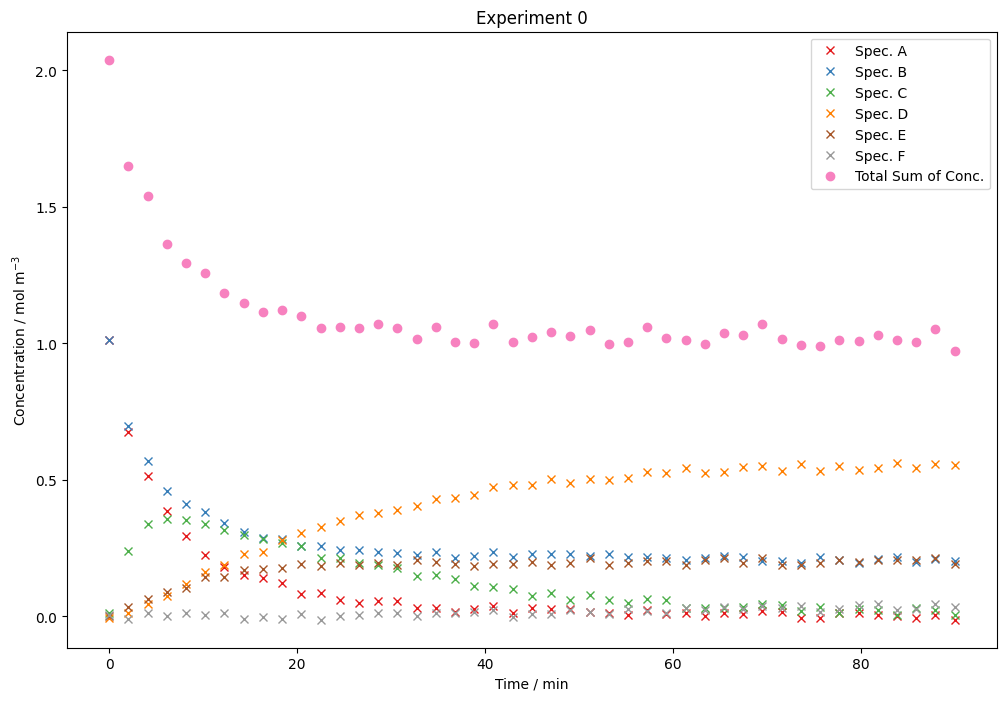

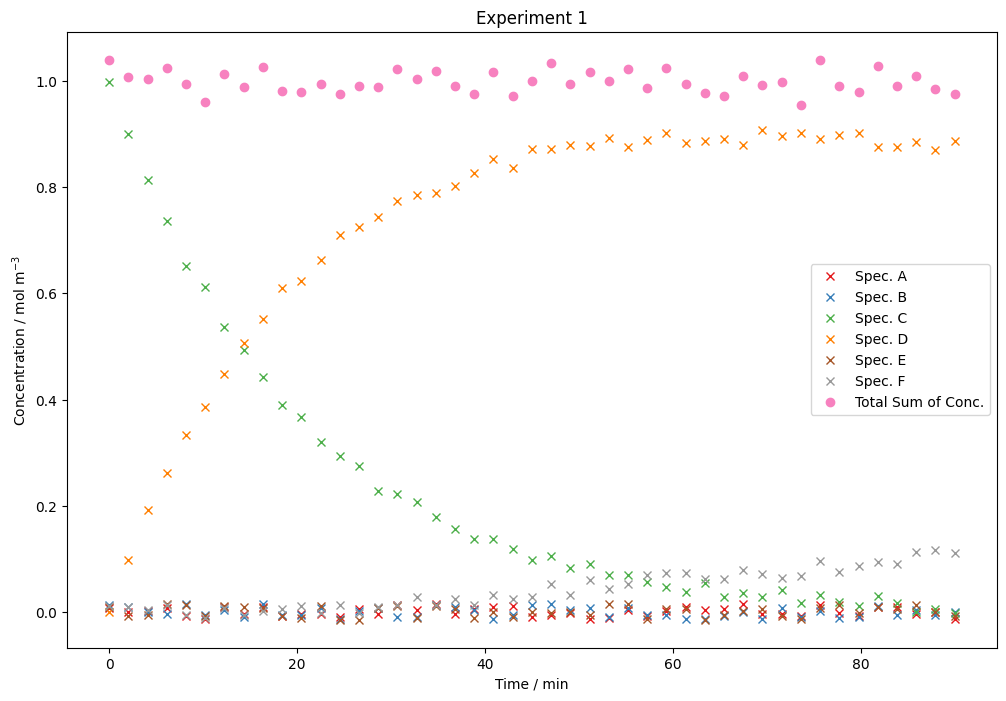

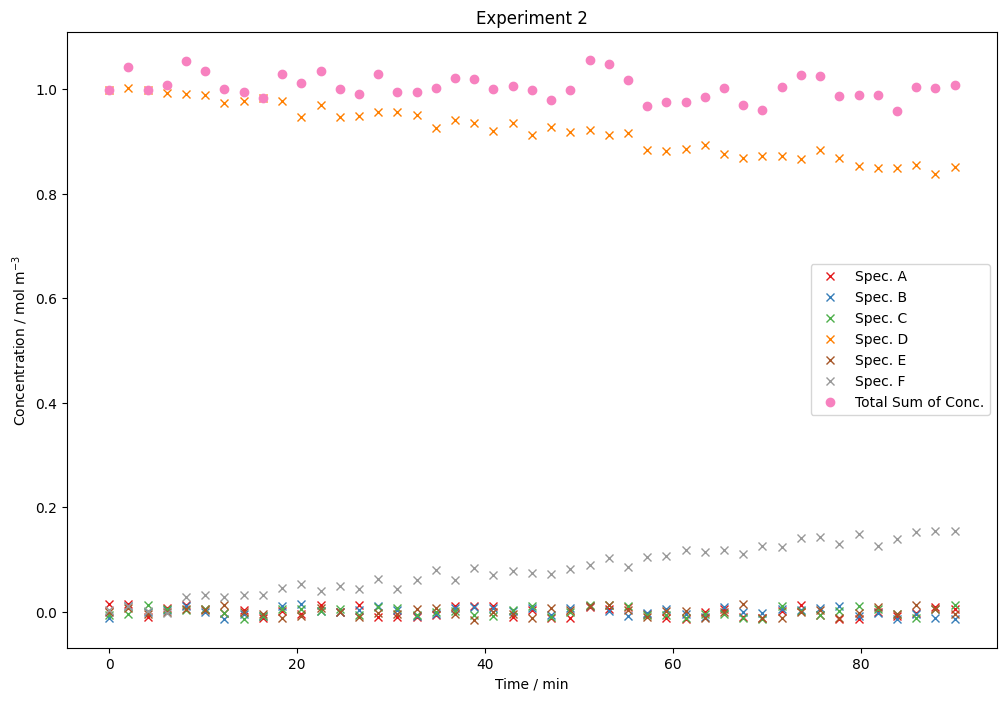

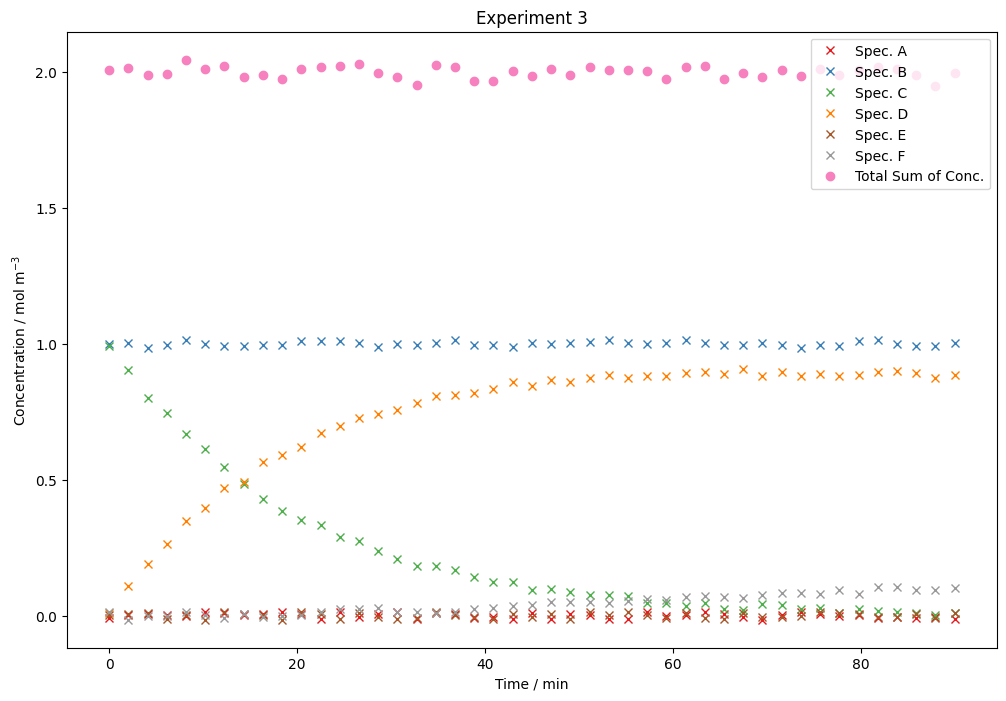

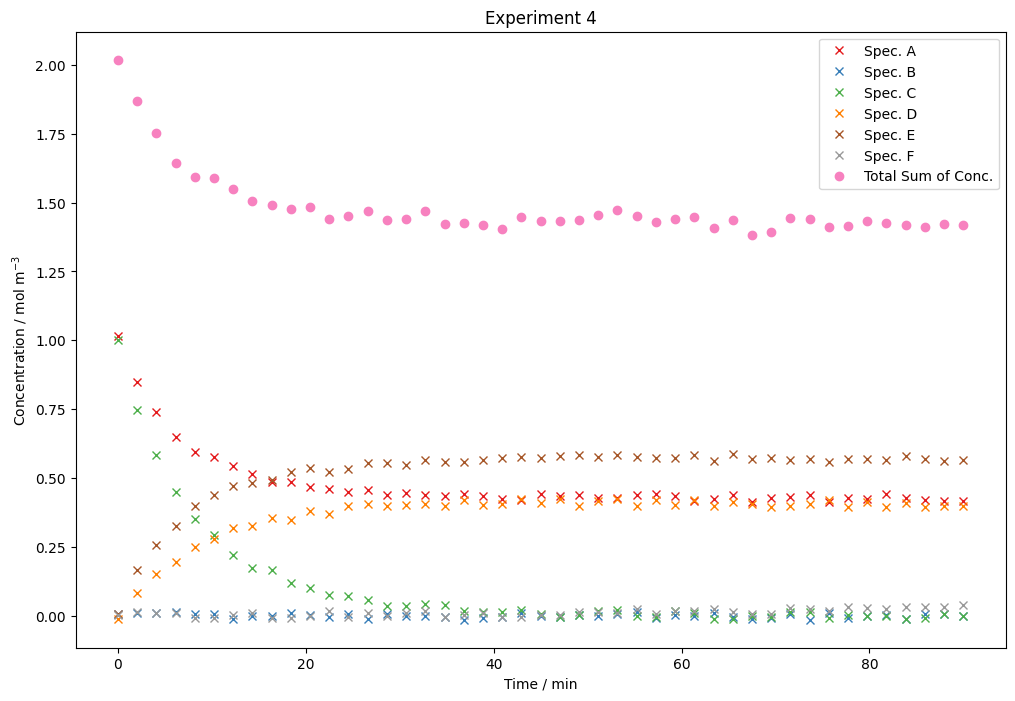

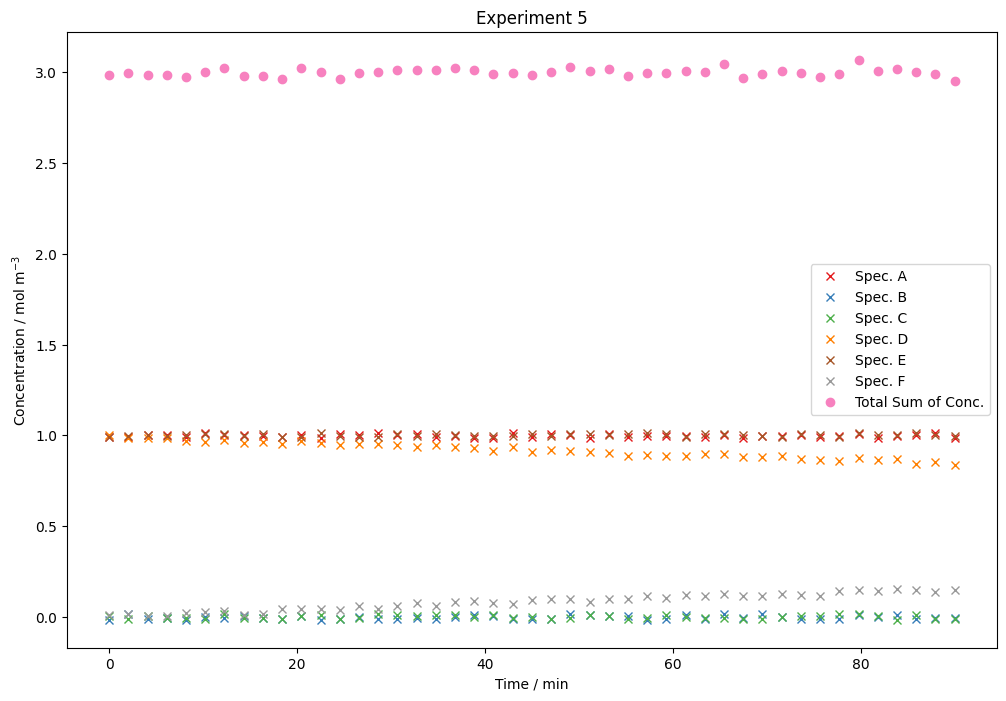

In [31]:
no_of_species = len(exp_conc[0])                                    # the number of species is equal to the length of the second dimension of the concentration array, which is 6
speciescount = np.array(["A","B","C","D","E","F"])                  # Naming Array for Legends in plotting
colors = colormaps.get_cmap('Set1')                                 # Getting a colormap from library, choice because of personal preference and visibility
colordivider = np.array([0,0.15,0.3,0.5,0.7,0.99])                  # Arrays with integers, to get the same colors for the same species in all diagrams

for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                     # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol m$^{-3}$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()

# 5. Deducing a Reaction Hypothesis

The best place to start is looking for experiments with the fewest converted species, because they enable us to make assumptions for species interactions without interference from possible side reactions.

### Experiment 5

Experiment 5 shows species D declining slightly, and an equal amount of species F being formed. This leads to the hypothesis:

$$1D \rightarrow 1F$$

Also, species A and E are present as educts but are not consumed. Species B and C also show no accumulation over time. This implies that the reactions

$$xA \rightarrow yB$$
$$xA \rightarrow yC$$
$$xE \rightarrow yB$$
$$xE \rightarrow yC$$

are not occurring, which we will adopt as our working hypothesis for now.

### Experiment 2

Experiment 2 shows the same behavior as Experiment 5, but with only species D as a possible educt. This further strengthens the hypothesis formulated above, and shows that the reaction paths

$$1A \rightarrow 1F$$

$$1E \rightarrow 1F$$

from Experiment 5 are unlikely.

### Experiment 3

Experiment 3 shows species C being consumed and species D being formed in a 1:1 ratio. From 40 minutes onwards we can also see the formation of species F, which is consistent with our hypothesis from Experiment 5. The newly formed species D is slowly consumed in the formation of species F:

$$1C \rightarrow 1D \rightarrow 1F$$

In this network of consecutive reactions, the reaction from C to D appears to be much faster than the reaction from D to F.

Also, species B is present as an educt but is not consumed. Therefore we hypothesize the following reactions to not be taking place:

$$xB \rightarrow yX$$
$$xB + yC \rightarrow xX + yY + zZ$$

Species B alone or in combination with C undergoes no reaction.

### Experiment 1

Experiment 1 shows the same behavior for species C, D and F as Experiment 3, but with only C as an educt. This strengthens all hypotheses from Experiment 3.

### Experiment 4

Experiment 4 shows species A and C as educts, and species D and E as formed products. We know from before that D can decay to species F, but this is indistinguishable from noise in this experiment. Species B does not appear to be formed at all. Species C is fully consumed, while species A retains a nonzero concentration. This is also the first time the total concentration changes, which means some reaction no longer has a 1:1 stoichiometric ratio. More species are consumed than formed; the total concentration decreases from 2 $\text{mol}\,\text{m}^{-3}$ to approximately 1.5 $\text{mol}\,\text{m}^{-3}$.

We know from Experiment 5 that the combinations of species A and E, A and D, or E and D do not react. Therefore, we hypothesize that E is not involved in any further reaction and is simply formed.

Experiments 3 and 1 showed a 1:1 ratio for the formation of D from C, yet here only half as much D is formed as C is consumed. Species C must therefore be involved in the formation of E. We hypothesize the following reactions to be occurring:

$$1A + 1C \rightarrow 1E$$
$$1C \rightarrow 1D$$
$$1D \rightarrow 1F \text{ (slow)}$$

### Experiment 0

Experiment 0 is the first time B is consumed, and the only experiment in which it exists alongside only species A. Therefore, we hypothesize that A and B react with each other. As species C exhibits the highest initial formation rate, it is reasonable to assume that C is being formed. This gives a 2:1 consumption-to-formation ratio, consistent with the total concentration decrease observed:

$$1A + 1B \rightarrow 1C$$

C is formed and, after reaching a peak, begins to be consumed. This is most likely due to the conversion of C into D, as seen in Experiments 1 and 3. C is also involved in the formation of E with species A, which explains the total consumption of A while B retains a nonzero concentration.

## Summary

The proposed hypothesis predicts the following reaction network:

$$1A + 1C \rightarrow 1E$$
$$1A + 1B \rightarrow 1C$$
$$1C \rightarrow 1D$$
$$1D \rightarrow 1F$$

The reaction from D to F is very slow. We can also conclude that reaction 1 is faster than reaction 3 (as seen in Experiment 4).

# 6. Parameter Estimation

In the following code cells, we define functions to automatically solve the resulting ODEs for the 
hypothesized reaction network. The inner workings of each function are detailed within the code 
cells with the help of code comments.

The general approach is as follows:

### Formulation of ODEs

From the reaction network, we derive reaction rates for each reaction, and from those the ODEs for 
each species, both in accordance with the fundamentals outlined previously:

\begin{aligned}
    &r_0 =& &k_0 \, c_A^{n_0} \, c_C^{n_1} \\
    &r_1 =& &k_1 \, c_A^{n_2} \, c_B^{n_3} \\
    &r_2 =& &k_2 \, c_C^{n_4} \\
    &r_3 =& &k_3 \, c_D^{n_5}
\end{aligned}

\begin{aligned}
    &\frac{d c_{A}}{d t} =& -& r_0 - r_1 \\
    &\frac{d c_{B}}{d t} =& -& r_1 \\
    &\frac{d c_{C}}{d t} =& -& r_0 - r_2 + r_1 \\
    &\frac{d c_{D}}{d t} =& -& r_3 + r_2 \\
    &\frac{d c_{E}}{d t} =& +& r_0 \\
    &\frac{d c_{F}}{d t} =& +& r_3 \\
\end{aligned}

To implement these, we defined the function `ode`, which calculates the concentration change for 
one time step.

### Programming a Function to Solve the ODE

The scipy function `solve_ivp` takes an ODE function (which we implemented in the previous step) 
and solves it for a given set of times. When calling the function, we provide:

- **fun**: the ODE function (in our case `ode`)
- **t_span**: a time span between two integers for the solver to solve the function in
- **y0**: the initial concentration values at the beginning of the experiments 
  (`ivp` stands for **I**nitial **V**alue **P**roblem, as it requires a starting point 
  to calculate subsequent points)
- **method**: a mathematical method for the solver to use (complex mathematics; can be used to 
  further tune the solver if you know the underlying theory. We used the method from the example, 
  as in-depth mathematics was beyond the scope of this assignment)
- **t_eval**: the exact time points at which to evaluate the ODEs
- **args**: additional arguments for the function. We defined $k$ as an argument, 
  so we need to pass it here.

We wrap the solver inside a callable function so that it can be called from within other functions.

### Using the Solver for Multiple Experiments

We defined the function `sim_multiple_exps` to simulate all experiments with one function call. 
This is necessary because the `lmfit` method requires a single return value, so we need to 
consolidate the results of all simulations into a single return value.

### Defining a Function for lmfit

The `estimator` function takes initial guesses for the reaction parameters and calls the 
multiple-experiment simulation function. The ODEs for each experiment and species are then 
solved by the functions above, and the results are passed back to the estimator function. 
This function, in turn, compares these results with the given experimental data and evaluates 
the error. If the error is not sufficiently small, it adjusts the given parameters and calls 
the simulator again, starting the whole process anew. If the error is deemed sufficiently small, 
it stops the iteration process and returns the fitted set of parameters along with the fitting 
process data, e.g. the residual error $\chi^2$ or the confidence intervals for the parameters.

In [32]:
def ode(t, c, k):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation;\\
    c: array
        concentration values at time t, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """

    c = np.maximum(c, 0) # to avoid negative concentrations, which can cause problems with the power function, we set all negative values to 0. This is reasonable, as negative concentrations are not physically meaningful.
    
    # calculating reaction rates
    r0 = k[0] * c[0] * c[2]
    r1 = k[1] * c[0] * c[1]
    r2 = k[2] * c[2]
    r3 = k[3] * c[3]

    #calculating the derivatives
    dcdt = np.zeros_like(c)         # initialises an array filled with zeros with the exact same shape as the array of given concentrations c
    dcdt[0] = - r0 -r1 
    dcdt[1] = - r1
    dcdt[2] = + r1 - r2 - r0
    dcdt[3] = + r2 - r3
    dcdt[4] = + r0
    dcdt[5] = + r3
    return dcdt

In [33]:
def solver(t, init_conc, k):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]\\
    init_conc: array
        initial concentrations, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    solution = scp.solve_ivp(fun=ode, t_span=[t[0],t[-1]], y0=init_conc, method = 'LSODA', t_eval=t, args=[k])
    return solution.y


In [34]:
def sim_multiple_exps(times, k0, k1, k2, k3, c_inits):
    """
    Simulate results for n experiments with nc components and 4 reactions. Each experiment has nt_i entries. 
    Note: This had to be modified from the example Code, because in this Case there are (presumably) 4 Reactions.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]\\
    k0: float
        Kinetic parameter of first reaction\\
    k1: float
        Kinetic parameter of second reaction\\
    k2: float
        Kinetic parameter of third reaction\\
    k3: float
        Kinetic Paramtere of fourth reaction\\
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]\\


    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = solver(t, c_0, k)
        sim_concs.append(conc)
    return sim_concs

### limfit for Parameter Estimation

In [35]:
def estimator(params, t, initial_concs, actual_data):
    """
    Minimizes the Difference between simulated Data and given experimental Data through iteration, changing the parameters to fit every Iteration

    Parameters
    -----------
    params:
        the parameters we want to change and fit through iteration\\
    t:
        Measurements times of the experiments, in the Format of a List of arrays\\
    actual_data:
        actual Data from the experiments, List of arrays \\
    initial_concs:
        initial concentrations of each experiment, List of arrays\\

    Returns
    ----------
    diff:
        difference between simulated result and actual Data
    """

    sim_res = sim_multiple_exps(t, params["k0"], params["k1"], params["k2"], params["k3"], initial_concs) # returns a List of arrayss, with the Results for experiment 0-5
    flat_sim_res = np.array([]) # empty array to store simulated Data in for comparison with experimental Data
    nex = len(t)
    for i in np.arange(0,nex):
        flat_sim_res = np.append(flat_sim_res, sim_res[i])

    return flat_sim_res - actual_data

## Calling the lmfit Function

To call the lmfit minimizer, we first need to make initial guesses for $k$. We choose 0.5 for 
each, as a neutral starting point for the estimation. We also need to provide minimum and maximum 
bounds, to prevent the solver from converging to unrealistic values that satisfy the mathematical 
constraints but lack physical meaning. For that, we choose a range from 0 to 10, which is a 
typical range for kinetic rate constants. [1] For the initial estimation, we fix the reaction 
order $n$ at 1 for all reactions.

In [36]:
import lmfit

params = lmfit.Parameters()
params.add('k0', value = 0.5, min = 0, max = 10, vary = True)
params.add('k1', value = 0.5, min = 0, max = 10, vary = True)
params.add('k2', value = 0.5, min = 0, max = 10, vary = True)
params.add('k3', value = 0.5, min = 0, max = 10, vary = True)

minimized_res = lmfit.Minimizer(estimator, params, fcn_args=(exp_time, init_c_val, ExperimentalData))
result = minimized_res.minimize()
lmfit.report_fit(result)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 56
    # data points      = 1620
    # variables        = 4
    chi-square         = 0.27079980
    reduced chi-square = 1.6757e-04
    Akaike info crit   = -14080.4222
    Bayesian info crit = -14058.8615
[[Variables]]
    k0:  0.09598296 +/- 5.5887e-04 (0.58%) (init = 0.5)
    k1:  0.19783193 +/- 0.00186376 (0.94%) (init = 0.5)
    k2:  0.05032942 +/- 1.8977e-04 (0.38%) (init = 0.5)
    k3:  0.00161163 +/- 1.6170e-05 (1.00%) (init = 0.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(k0, k2) = +0.4507
    C(k0, k1) = +0.2891
    C(k2, k3) = +0.1006


# 7. Plausibility Check

Since we cannot rely solely on computer output, we need to assess the results for plausibility 
and validate them. As a visual inspection is susceptible to human error, we assess the fit using 
quantitative error metrics. For this, we have chosen the coefficient of determination $R^2$ and 
the root mean square error (RMSE). The lmfit minimizer also provides the error metric $\chi^2$, 
which we can use for additional validation.

The metrics are defined as follows:

### $\chi^2$

$\chi^2$ measures the overall deviation between the simulated and experimental data. Lower values 
of $\chi^2$ indicate a better fit. $\chi^2$ is calculated as:

$$\chi^2 = \sum_{i=1}^{N} \left( y_{i,\mathrm{exp}} - y_{i,\mathrm{sim}} \right)^2$$

### RMSE

The root mean squared error computes the squared differences between the simulated values 
$y_{i,\mathrm{sim}}$ and experimental values $y_{i,\mathrm{exp}}$, sums them, divides the result 
by the total number of measurement points, and takes the square root. This yields the average 
deviation between the simulated and experimental values. A low RMSE indicates a good fit, as the 
simulated data does not deviate much from the experimental measurements. The RMSE should always 
be interpreted in the context of the data scale.

$$\mathrm{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left( y_{i,\mathrm{exp}} - y_{i,\mathrm{sim}} \right)^2}$$

### $R^2$

The coefficient of determination describes how much of the variance in the experimental data is 
explained by the model. The value of $R^2$ ranges from $-\infty$ to 1, with 1 being a perfect 
fit. Values close to 1 indicate a good fit. It should be noted that $R^2$ is not defined for 
constant values, as this would result in division by zero. For near-constant data, this metric 
is not meaningful and should be disregarded.

$$R^2 = 1 - \frac{\sum_{i=1}^{N} \left( y_{i,\mathrm{exp}} - y_{i,\mathrm{sim}} \right)^2}{\sum_{i=1}^{N} \left( y_{i,\mathrm{exp}} - \bar{y}_{\mathrm{exp}} \right)^2}$$

## $R^2$

In [49]:
# Calculating the coefficient of determination for each species in each experiment individually
def R2_for_each_exp(exp_concentration, sim_res):
    '''
    Calculates the coefficient of determination for each species in each experiment individually

    Parameters
    ----------
    exp_concentration: List
        List of arrays with the experimental concentrations for each species in each experiment, size: [n_experiments][n_species, n_measurements]
    sim_res: List
        List of arrays with the simulated results for each species in each experiment, size: [n_experiments][n_species, n_measurements]

    Returns
    ----------
    R2_for_each: List
        List of stirngs with the result for each Species and Experiment listet for better readability, size: [n_experiments_times_species]
    '''
    R2_for_each = []
    for i in range(len(exp_concentration)):                                                         # Number of Experiments
        for j in range(len(exp_concentration[i])):                                                  # Species in the Experiment
            c_med = np.mean(exp_concentration[i][j])                                                # calculates the mean value y of species j in Experiment i
            #calculation of R^2, for in depth explanation look up definition of coefficient of determination
            SQR = np.sum((exp_concentration[i][j]-sim_res[i][j])**2)
            SQT = np.sum((exp_concentration[i][j]-c_med)**2)
            R2  = 1 - (SQR/SQT)
            R2_for_each = np.append(R2_for_each, "Experiment " + str(i) + ", Species " + speciescount[j] + ": " + str(R2.round(5)))
    return R2_for_each

# Calculating the coefficient of determination for all Measuring points over all Experiments and species together
def R2_total(sim_data, actual_data):
    '''
    Calculate the total coefficient of determination for all measuring points over all Experiments combined.
    Parameters
    ----------
    sim_data: list
        List of arrays with the simulated results for each species and experiment, size [n_experiments][n_species, n_measurements]\\
    actual_data: list
        flat list (1D) with all experimentally measured values, size [n_measurements_total]
    
    Returns
    ----------
    R2_total: float
        value for the coefficient of determination over all experiments, size: 1
    '''
    sim_res_flat = []
    for i in range(len(sim_data)):
        sim_res_flat = np.append(sim_res_flat, sim_data[i])
    SQR_tot = np.sum((actual_data - sim_res_flat)**2 )
    SQT_tot = np.sum((actual_data - np.mean(actual_data))**2)
    R2_total = 1 - (SQR_tot/SQT_tot)
    return R2_total.round(5)

## RMSE

In [48]:
def RMSE(exp_concentration, sim_res):
    '''
    Calculates the RMSE for each species in each experiment individually

    Parameters
    ----------
    exp_concentration: List
        List of arrays with the experimental concentrations for each species in each experiment, size: [n_experiments][n_species, n_measurements]
    sim_res: List
        List of arrays with the simulated results for each species in each experiment, size: [n_experiments][n_species, n_measurements]

    Returns
    ----------
    RMSE_for_each: List
        List of stirngs with the result for each Species and Experiment listet for better readability, size: [n_experiments_times_species]
    '''
    RMSE_for_each = []

    for i in range(len(exp_concentration)):                                             # Number of Experiments
        for j in range(len(exp_concentration[i])):                                                  # Species in the Experiment
            #calculation of RMSE, for in depth explanation look up definition of coefficient of determination
            RMSE  = np.sqrt(np.sum((exp_concentration[i][j] - sim_res[i][j])**2)/len(exp_concentration[i][j]))
            RMSE_for_each = np.append(RMSE_for_each, "Experiment " + str(i) + ", Species " + speciescount[j] + ": " + str(RMSE.round(5)))
    return RMSE_for_each

def RMSE_total(sim_data, actual_data):
    '''
    Calculates the total RMSE for all measuring points over all Experiments combined.

    Parameters
    ----------
    sim_data: list
        List of arrays with the simulated results for each species and experiment, size [n_experiments][n_species, n_measurements]\\
    actual_data: list
        flat list (1D) with all experimentally measured values, size [n_measurements_total]
    
    Returns
    ----------
    RMSE_total: float
        value for the coefficient of determination over all experiments, size: 1
    '''
    sim_res_flat = []
    for i in range(len(sim_data)):                                                              # flattens the simulated Data in a 1D array
        sim_res_flat = np.append(sim_res_flat, sim_data[i])
    RMSE_tot  = np.sqrt(np.sum((actual_data - sim_res_flat)**2)/len(actual_data))
    return RMSE_tot.round(5)

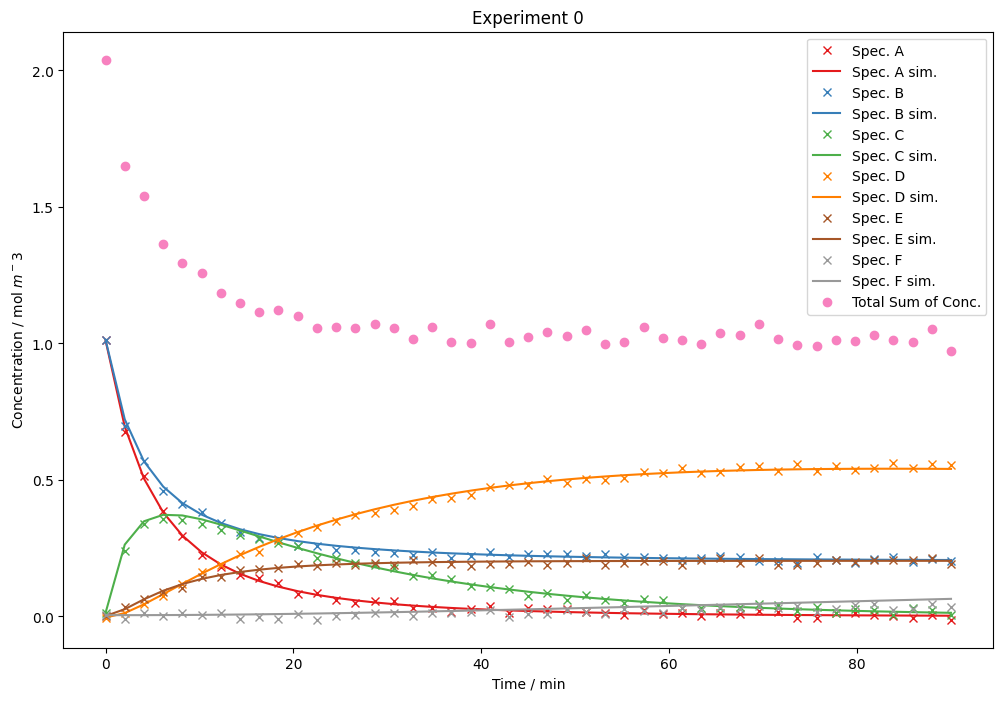

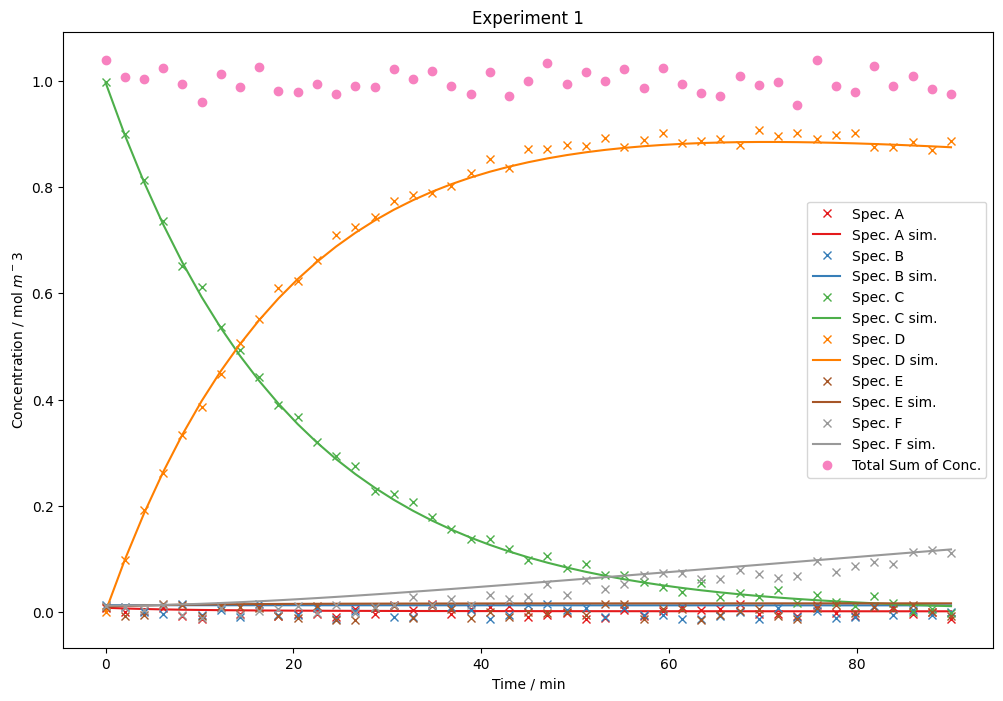

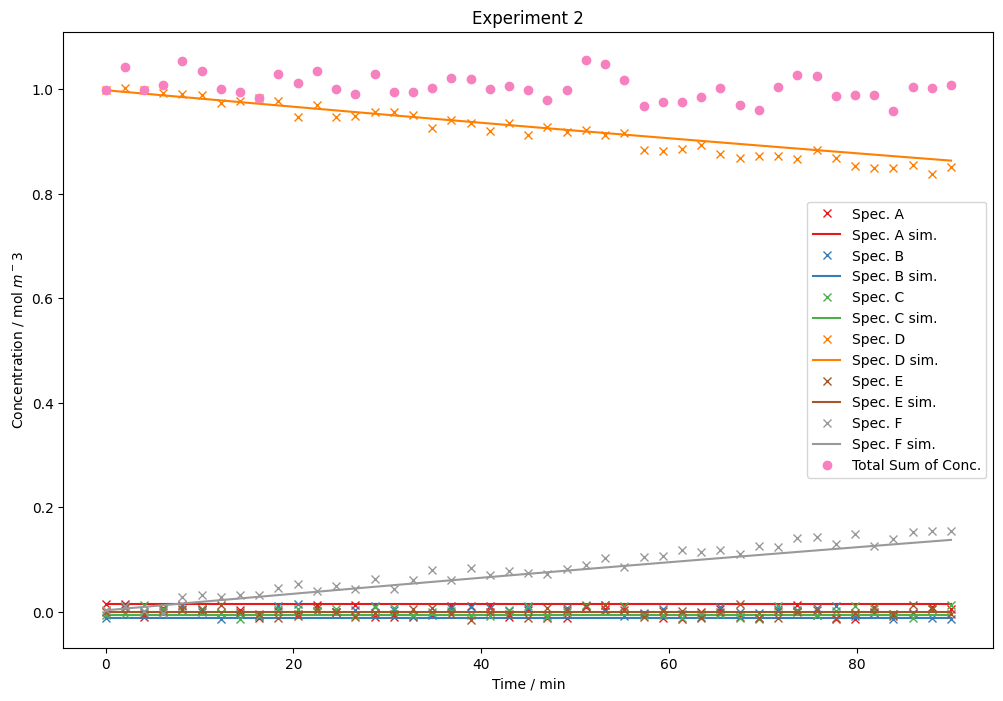

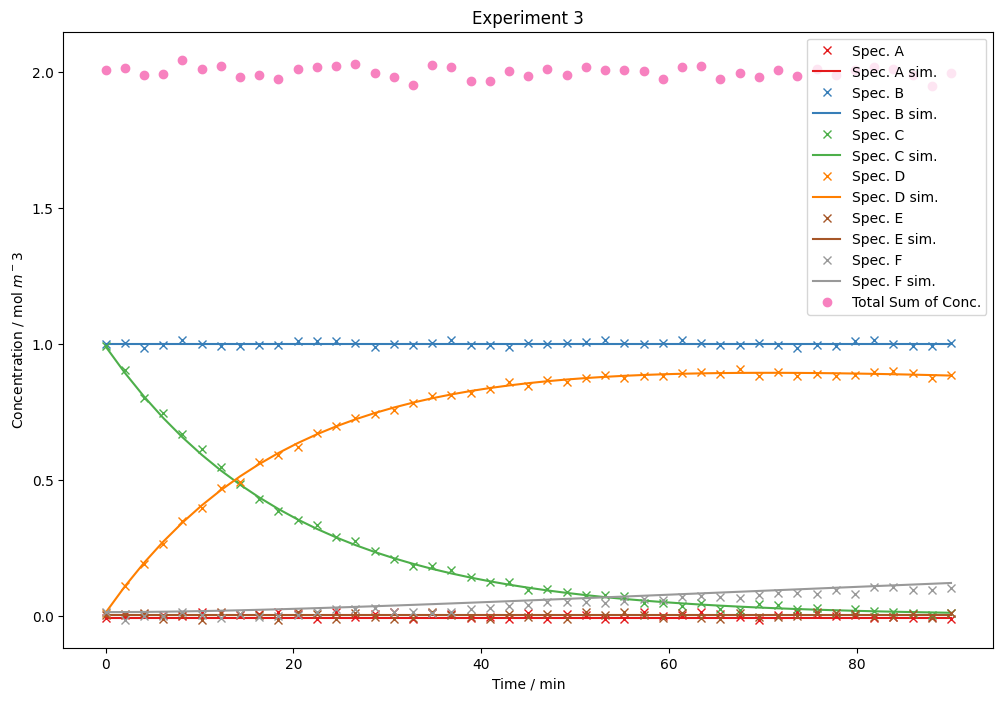

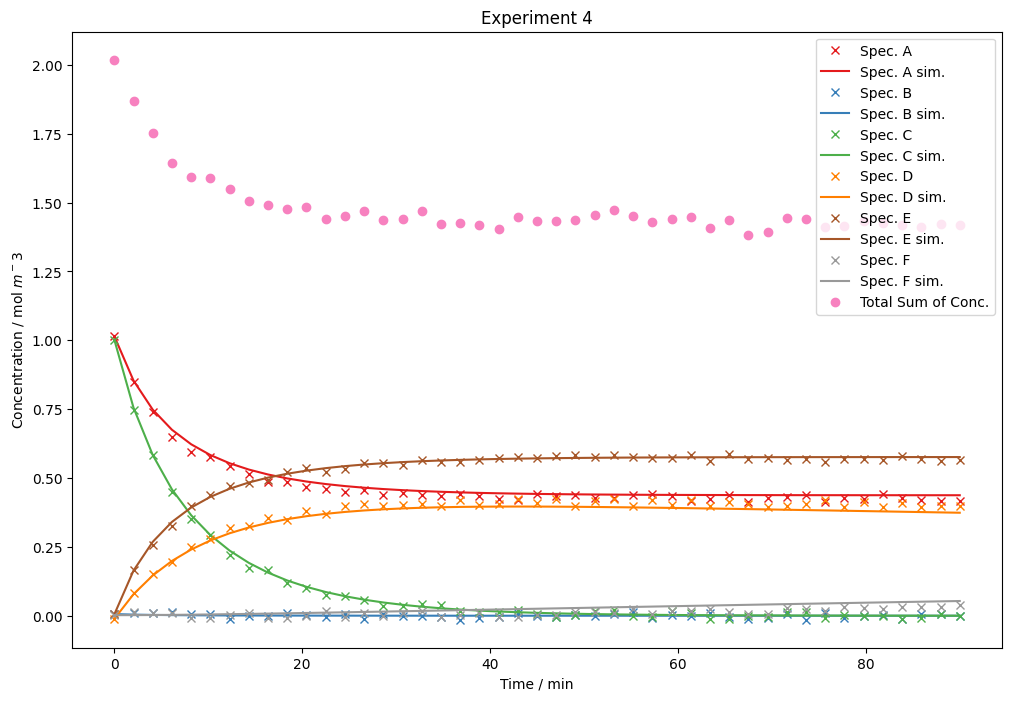

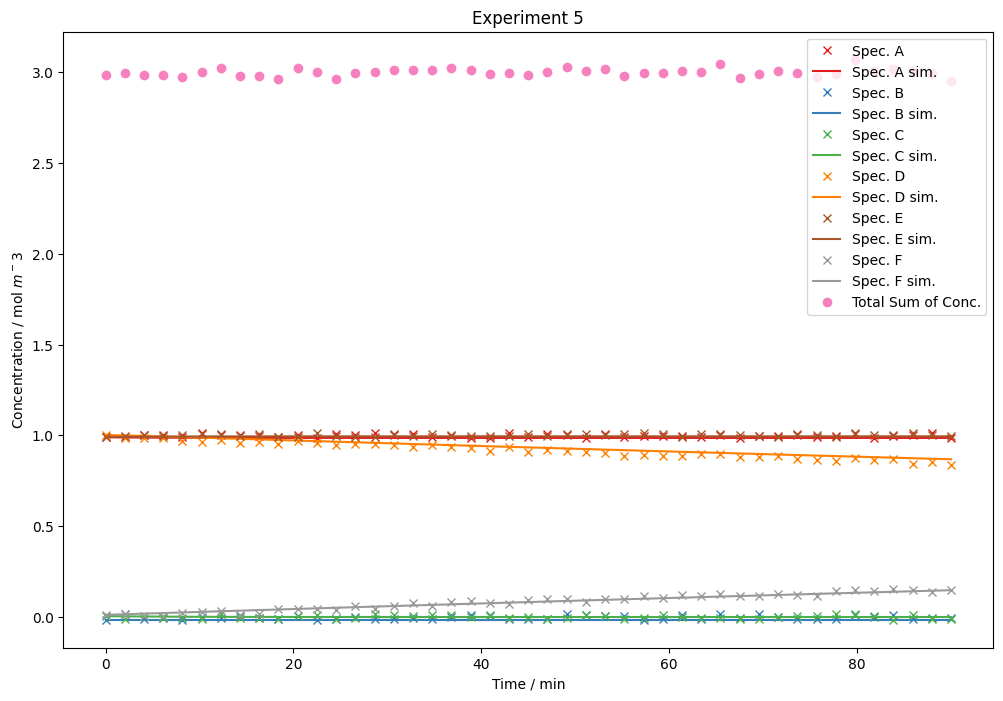

In [39]:
bestfit_res = sim_multiple_exps(exp_time, result.params["k0"], result.params["k1"], result.params["k2"], result.params["k3"], init_c_val)

for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                         # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.plot(exp_time[i], bestfit_res[i][j], label = "Spec. " + speciescount[j] + " sim.", color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol $m^-3$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()

In [50]:
print(R2_total(bestfit_res, ExperimentalData))
print(R2_for_each_exp(exp_conc, bestfit_res))

0.99872
['Experiment 0, Species A: 0.99788' 'Experiment 0, Species B: 0.99585'
 'Experiment 0, Species C: 0.99008' 'Experiment 0, Species D: 0.99624'
 'Experiment 0, Species E: 0.96707' 'Experiment 0, Species F: -0.3486'
 'Experiment 1, Species A: -0.05786' 'Experiment 1, Species B: -2.11134'
 'Experiment 1, Species C: 0.99885' 'Experiment 1, Species D: 0.99724'
 'Experiment 1, Species E: -2.40765' 'Experiment 1, Species F: 0.74567'
 'Experiment 2, Species A: -2.36902' 'Experiment 2, Species B: -2.71272'
 'Experiment 2, Species C: -0.52702' 'Experiment 2, Species D: 0.91625'
 'Experiment 2, Species E: -0.00544' 'Experiment 2, Species F: 0.91129'
 'Experiment 3, Species A: -1.27531' 'Experiment 3, Species B: -0.00307'
 'Experiment 3, Species C: 0.99882' 'Experiment 3, Species D: 0.99883'
 'Experiment 3, Species E: -0.10139' 'Experiment 3, Species F: 0.72859'
 'Experiment 4, Species A: 0.98407' 'Experiment 4, Species B: 0.07651'
 'Experiment 4, Species C: 0.99806' 'Experiment 4, Species 

In [51]:
print(RMSE(exp_conc, bestfit_res))
print(RMSE_total(bestfit_res, ExperimentalData))

['Experiment 0, Species A: 0.00898' 'Experiment 0, Species B: 0.00956'
 'Experiment 0, Species C: 0.0111' 'Experiment 0, Species D: 0.01014'
 'Experiment 0, Species E: 0.00843' 'Experiment 0, Species F: 0.01681'
 'Experiment 1, Species A: 0.00834' 'Experiment 1, Species B: 0.0159'
 'Experiment 1, Species C: 0.0089' 'Experiment 1, Species D: 0.01246'
 'Experiment 1, Species E: 0.01769' 'Experiment 1, Species F: 0.01847'
 'Experiment 2, Species A: 0.01724' 'Experiment 2, Species B: 0.01509'
 'Experiment 2, Species C: 0.01012' 'Experiment 2, Species D: 0.01414'
 'Experiment 2, Species E: 0.00787' 'Experiment 2, Species F: 0.0135'
 'Experiment 3, Species A: 0.01379' 'Experiment 3, Species B: 0.00783'
 'Experiment 3, Species C: 0.00903' 'Experiment 3, Species D: 0.00797'
 'Experiment 3, Species E: 0.00966' 'Experiment 3, Species F: 0.01846'
 'Experiment 4, Species A: 0.0149' 'Experiment 4, Species B: 0.00741'
 'Experiment 4, Species C: 0.00925' 'Experiment 4, Species D: 0.01865'
 'Experimen

## Results from the first parameter estimation

| Parameter | Value | Standart deviation | Relative deviation |
|---|---|---|---|
| $k_0$ | 0.09598 | $5.58 \cdot 10^{-4}$ | 0.58% |
| $k_1$ | 0.19783 | $1.86 \cdot 10^{-3}$ | 0.94% |
| $k_2$ | 0.05033 | $1.90 \cdot 10^{-4}$ | 0.38% |
| $k_3$ | 0.00161 | $1.62 \cdot 10^{-5}$ | 1.00% |


| Error Metric | Value |
|---|---|
| $R^2$     | 0.9987 |
| RMSE      | 0.0129 |
| $\chi^2$  | 0.2708 |

The initial visual inspection (above) appears promising; there are no significant deviations 
between the simulated results and the experimental data. Furthermore, the resulting values of $k$ 
are within the expected range. The value of $k_3$ is by far the lowest, which is expected, as 
the reaction from D to F was shown to have the slowest conversion rate. The value of $k_1$ is 
the highest, which is also consistent with our expectations. From Experiment 0, we can see that 
the formation of C from A and B is the fastest observed reaction, for which the simulated value 
is consistent with this. $k_0$ and $k_2$ show intermediate values, which is also consistent with 
the experimental data.

The value of $\chi^2$ is returned from the minimizer as 0.027. This is a small value which, by 
definition, indicates a good initial fit.

For $R^2$, we observe values close to 1 for each experiment–species combination in which the 
species concentration is not approximately constant throughout the experiment. For near-constant 
concentrations, the results are considerably worse. This is because the coefficient of 
determination is undefined for a constant set of measured values, as this would require division 
by zero (as clarified above). The only reason division by zero does not occur is that measurement 
errors exist even for nominally constant concentrations, resulting in slight variation. 
Nonetheless, for near-constant data, this metric is not meaningful and should be disregarded.

In cases where the coefficient of determination is applicable, we almost always obtain values 
above 0.95, which indicates a very good fit.

The root mean squared error shows no significant variation across experiments, in contrast to 
the coefficient of determination $R^2$. This is because, unlike $R^2$, the RMSE measures 
absolute deviation rather than relative variation, and is therefore unaffected by whether a 
species concentration is constant.

It shows that, on average, our simulation deviates by approximately 0.0121 $\mathrm{mol\, m^{-3}}$. 
This deviation is very small and can, to a significant extent, be attributed to measurement 
uncertainty. Combined with the coefficient of determination and $\chi^2$, this demonstrates that 
the simulated results closely track the experimental measurements in both relative variation and 
absolute values. We therefore conclude that the simulation results are reliable.

# 8. Potential Improvement of Simulated Data with Additional Fit for Reaction Order

To additionally fit the reaction order, we copy the functions below and extend them with the 
functionality for estimating $n$. To do so, we pass $n$ as an argument through the functions 
and use it in the defined ODE. Compare the `_with_n` functions with those defined above to 
identify the modifications; refer also to the code comments.

We set the initial guess for $k$ in each reaction to the result of the first estimation. This 
is done because the solver converges considerably faster given an already optimized starting point.

In [55]:
def ode_with_n(t, c, k, n):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation;\\
    c: array
        concentration values at time t, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """

    c = np.maximum(c, 0) # to avoid negative concentrations, which can cause problems with the power function, we set all negative values to 0. This is reasonable, as negative concentrations are not physically meaningful.

    # calculating reaction rates
    r0 = k[0] * c[0]**n[0] * c[2]**n[1]
    r1 = k[1] * c[0]**n[2] * c[1]**n[3]
    r2 = k[2] * c[2]**n[4]
    r3 = k[3] * c[3]**n[5]

    #calculating the derivatives
    dcdt = np.zeros_like(c)         # initialises an array filled with zeros with the exact same shape as the array of given concentrations c
    dcdt[0] = - r0 -r1 
    dcdt[1] = - r1
    dcdt[2] = + r1 - r2 - r0
    dcdt[3] = + r2 - r3
    dcdt[4] = + r0
    dcdt[5] = + r3
    return dcdt

def solver_with_n(t, init_conc, k, n):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]\\
    init_conc: array
        initial concentrations, size [nc]\\
    k: array
        kinetic coefficients for all reactions, size [nr]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    solution = scp.solve_ivp(fun=ode_with_n, t_span=[t[0],t[-1]], y0=init_conc, method = 'LSODA', t_eval=t, args=[k, n])
    return solution.y

def sim_multiple_exps_with_n(times, k0, k1, k2, k3, n0, n1, n2, n3, n4, n5, c_inits):
    """
    Simulate results for n experiments with nc components and 4 reactions. Each experiment has nt_i entries. 
    Note: This had to be modified from the example Code, because in this Case there are (presumably) 4 Reactions.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]\\
    k0: float
        Kinetic parameter of first reaction\\
    k1: float
        Kinetic parameter of second reaction\\
    k2: float
        Kinetic parameter of third reaction\\
    k3: float
        Kinetic Paramtere of fourth reaction\\
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]\\
    n0: float
        reaction rate of first species first reaction
    n1: float
        reaction rate of second species first reaction
    n2: float
        reaction rate of first species second reaction
    n3: float
        reaction rate of second species second reaction
    n4: float
        reaction rate of first species third reaction
    n5: float
        reaction rate of first species fourth reaction

    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    k = [k0, k1, k2, k3]
    n = [n0, n1, n2, n3, n4, n5]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = solver_with_n(t, c_0, k, n)
        sim_concs.append(conc)
    return sim_concs

def estimator_with_n(params, t, initial_concs, actual_data):
    """
    Minimizes the Difference between simulated Data and given experimental Data through iteration, changing the parameters to fit every Iteration

    Parameters
    -----------
    params:
        the parameters we want to change and fit through iteration\\
    t:
        Measurements times of the experiments, in the Format of a List of arrays\\
    actual_data:
        actual Data from the experiments, List of arrays \\
    initial_concs:
        initial concentrations of each experiment, List of arrays\\

    Returns
    ----------
    diff:
        difference between simulated result and actual Data
    """

    sim_res = sim_multiple_exps_with_n(t, params["k0"], params["k1"], params["k2"], params["k3"], params["n0"], params["n1"], params["n2"], params["n3"], params["n4"], params["n5"], initial_concs) # returns a List of arrayss, with the Results for experiment 0-5
    flat_sim_res = np.array([]) # empty array to store simulated Data in for comparison with experimental Data
    nex = len(t)
    for i in np.arange(0,nex):
        flat_sim_res = np.append(flat_sim_res, sim_res[i])

    return flat_sim_res - actual_data

In [56]:
# We set the starting values for k to the vefore fitted results, to give the solver a better starting point and hence hopefully faster convergence. For the reaction rates n, we set the starting values to 1, which is the value for a reaction of order 1, which is a common case. 
# We also set the boundaries for n to 0 and 5, as negative reaction orders are not physically meaningful, and reaction orders above 5 are very uncommon and would make the model unnecessarily complex.
params_with_n = lmfit.Parameters()
params_with_n.add('k0', value = result.params['k0'], min = 0, max = 10, vary = True)
params_with_n.add('k1', value = result.params['k1'], min = 0, max = 10, vary = True)
params_with_n.add('k2', value = result.params['k2'], min = 0, max = 10, vary = True)
params_with_n.add('k3', value = result.params['k3'], min = 0, max = 10, vary = True)
params_with_n.add('n0', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n1', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n2', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n3', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n4', value = 1, min = 0, max = 5, vary = True)
params_with_n.add('n5', value = 1, min = 0, max = 5, vary = True)

minimized_res_with_n = lmfit.Minimizer(estimator_with_n, params_with_n, fcn_args=(exp_time, init_c_val, ExperimentalData))
result_with_n = minimized_res_with_n.minimize()
lmfit.report_fit(result_with_n)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 156
    # data points      = 1620
    # variables        = 10
    chi-square         = 0.20497980
    reduced chi-square = 1.2732e-04
    Akaike info crit   = -14519.5409
    Bayesian info crit = -14465.6391
[[Variables]]
    k0:  0.09705515 +/- 0.00190491 (1.96%) (init = 0.09598296)
    k1:  0.19393552 +/- 0.00360347 (1.86%) (init = 0.1978319)
    k2:  0.04994671 +/- 3.4387e-04 (0.69%) (init = 0.05032942)
    k3:  0.00194511 +/- 2.4940e-05 (1.28%) (init = 0.001611627)
    n0:  1.00715318 +/- 0.01740745 (1.73%) (init = 1)
    n1:  0.99398820 +/- 0.02383988 (2.40%) (init = 1)
    n2:  1.09886875 +/- 0.01854732 (1.69%) (init = 1)
    n3:  0.84737513 +/- 0.00203071 (0.24%) (init = 1)
    n4:  1.00724224 +/- 0.00747654 (0.74%) (init = 1)
    n5:  2.21342147 +/- 0.08221681 (3.71%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(k0, n3) = -0.9807
    C(n1, n3) = -0.9041
    C(k0, n1) = +0.868

In [52]:
bestfit_res_with_n = sim_multiple_exps_with_n(exp_time, result_with_n.params["k0"], result_with_n.params["k1"], result_with_n.params["k2"], result_with_n.params["k3"], result_with_n.params["n0"], result_with_n.params["n1"], result_with_n.params["n2"], result_with_n.params["n3"], result_with_n.params["n4"], result_with_n.params["n5"], init_c_val)

In [53]:
print(R2_for_each_exp(exp_conc, bestfit_res_with_n))
print(R2_total(bestfit_res_with_n, ExperimentalData))

['Experiment 0, Species A: 0.99782' 'Experiment 0, Species B: 0.99416'
 'Experiment 0, Species C: 0.99034' 'Experiment 0, Species D: 0.99532'
 'Experiment 0, Species E: 0.9578' 'Experiment 0, Species F: 0.65595'
 'Experiment 1, Species A: -0.05974' 'Experiment 1, Species B: -2.1029'
 'Experiment 1, Species C: 0.99906' 'Experiment 1, Species D: 0.99831'
 'Experiment 1, Species E: -2.38997' 'Experiment 1, Species F: 0.87796'
 'Experiment 2, Species A: -2.36902' 'Experiment 2, Species B: -2.71272'
 'Experiment 2, Species C: -0.52702' 'Experiment 2, Species D: 0.95742'
 'Experiment 2, Species E: -0.00544' 'Experiment 2, Species F: 0.96372'
 'Experiment 3, Species A: -1.27531' 'Experiment 3, Species B: -0.00307'
 'Experiment 3, Species C: 0.9989' 'Experiment 3, Species D: 0.99827'
 'Experiment 3, Species E: -0.10139' 'Experiment 3, Species F: 0.87168'
 'Experiment 4, Species A: 0.99129' 'Experiment 4, Species B: 0.04177'
 'Experiment 4, Species C: 0.99801' 'Experiment 4, Species D: 0.98643'

In [54]:
print(RMSE(exp_conc, bestfit_res_with_n))
print(RMSE_total(bestfit_res_with_n, ExperimentalData))

['Experiment 0, Species A: 0.0091' 'Experiment 0, Species B: 0.01134'
 'Experiment 0, Species C: 0.01095' 'Experiment 0, Species D: 0.01132'
 'Experiment 0, Species E: 0.00954' 'Experiment 0, Species F: 0.00849'
 'Experiment 1, Species A: 0.00835' 'Experiment 1, Species B: 0.01588'
 'Experiment 1, Species C: 0.00803' 'Experiment 1, Species D: 0.00975'
 'Experiment 1, Species E: 0.01765' 'Experiment 1, Species F: 0.01279'
 'Experiment 2, Species A: 0.01724' 'Experiment 2, Species B: 0.01509'
 'Experiment 2, Species C: 0.01012' 'Experiment 2, Species D: 0.01008'
 'Experiment 2, Species E: 0.00787' 'Experiment 2, Species F: 0.00863'
 'Experiment 3, Species A: 0.01379' 'Experiment 3, Species B: 0.00783'
 'Experiment 3, Species C: 0.00872' 'Experiment 3, Species D: 0.0097'
 'Experiment 3, Species E: 0.00966' 'Experiment 3, Species F: 0.01269'
 'Experiment 4, Species A: 0.01102' 'Experiment 4, Species B: 0.00755'
 'Experiment 4, Species C: 0.00937' 'Experiment 4, Species D: 0.0107'
 'Experim

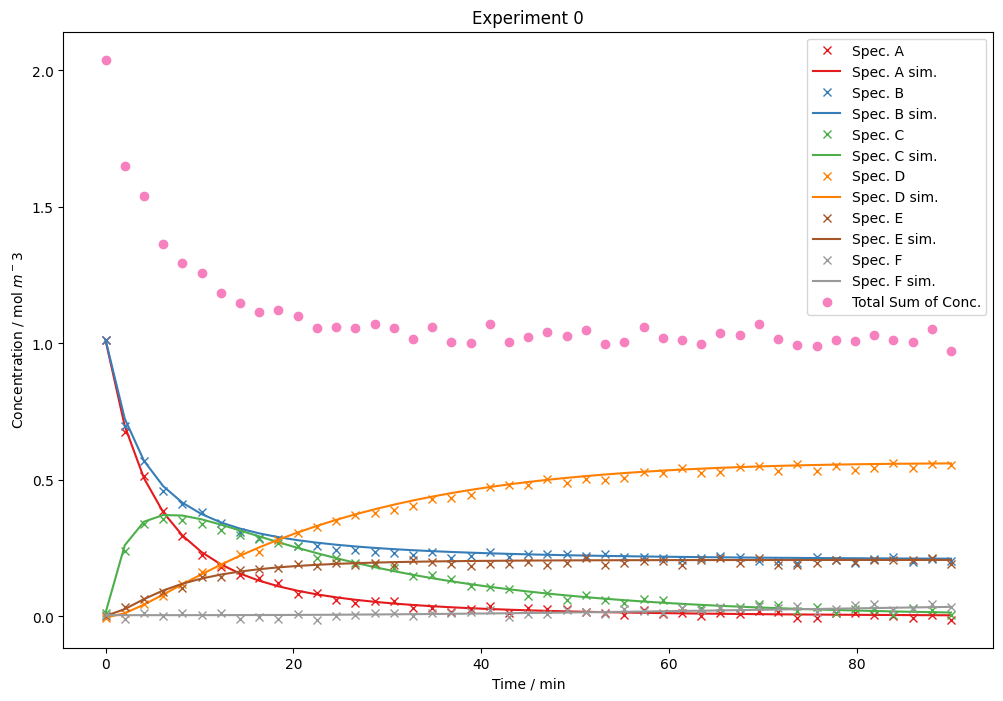

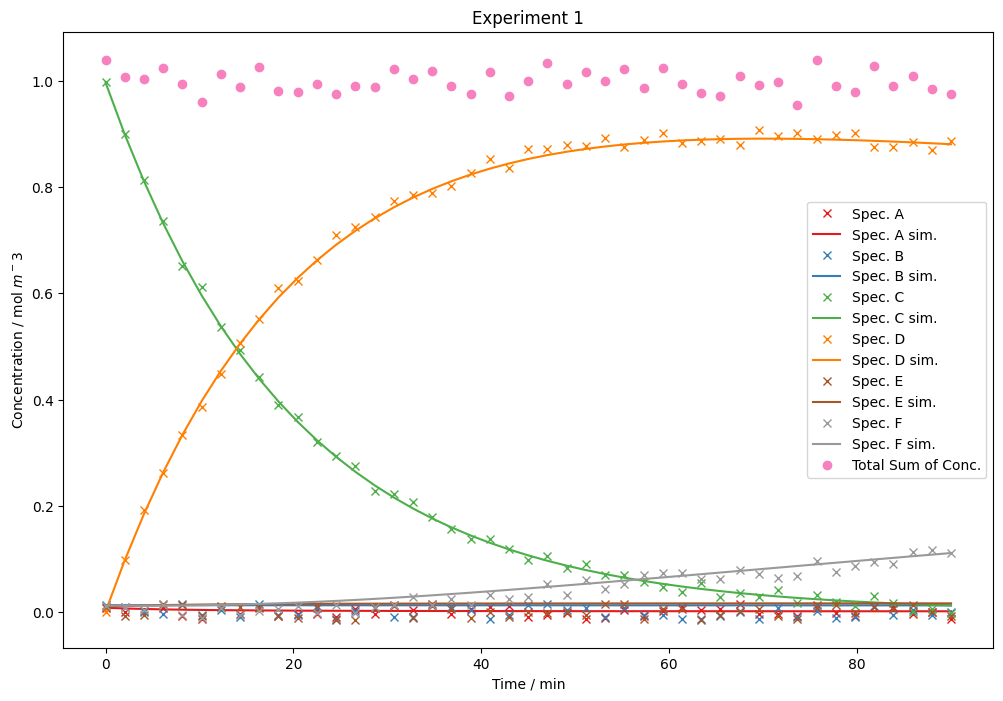

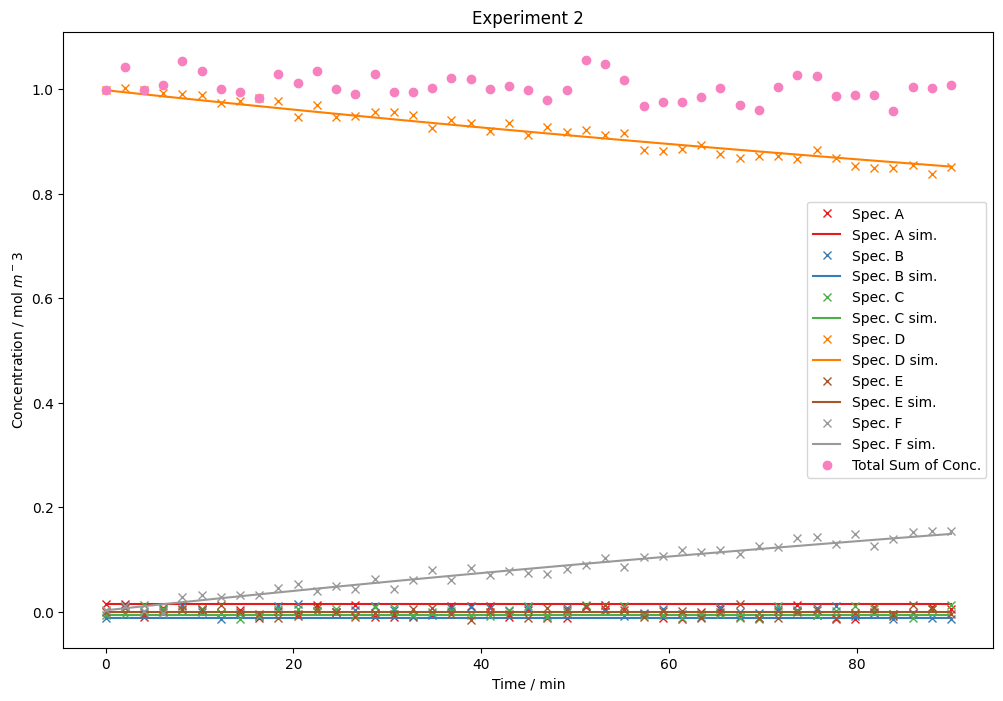

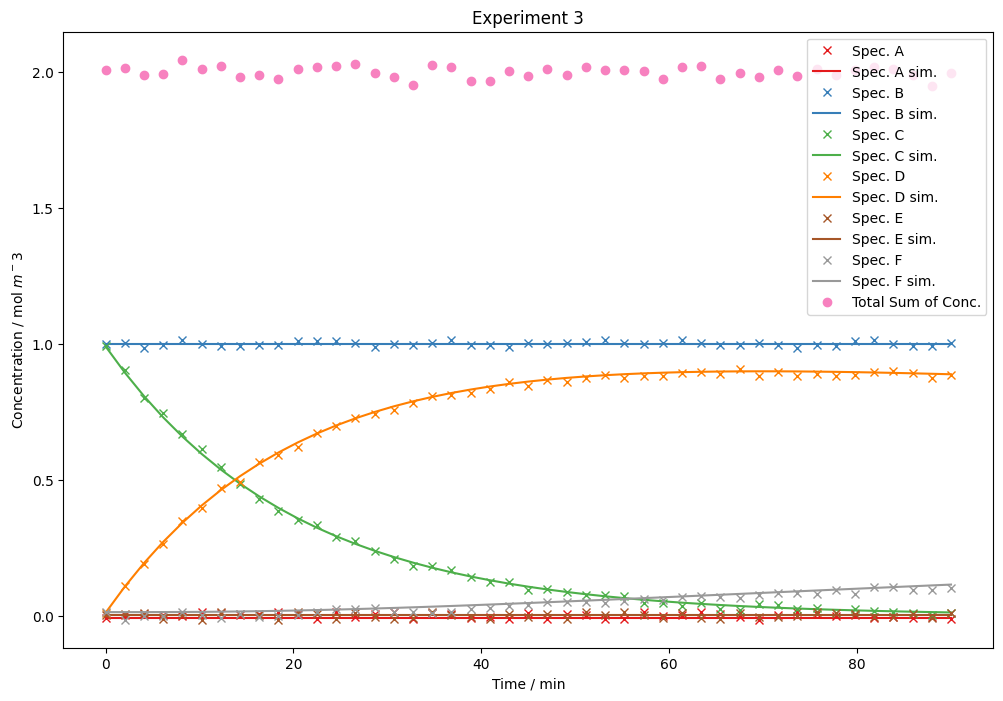

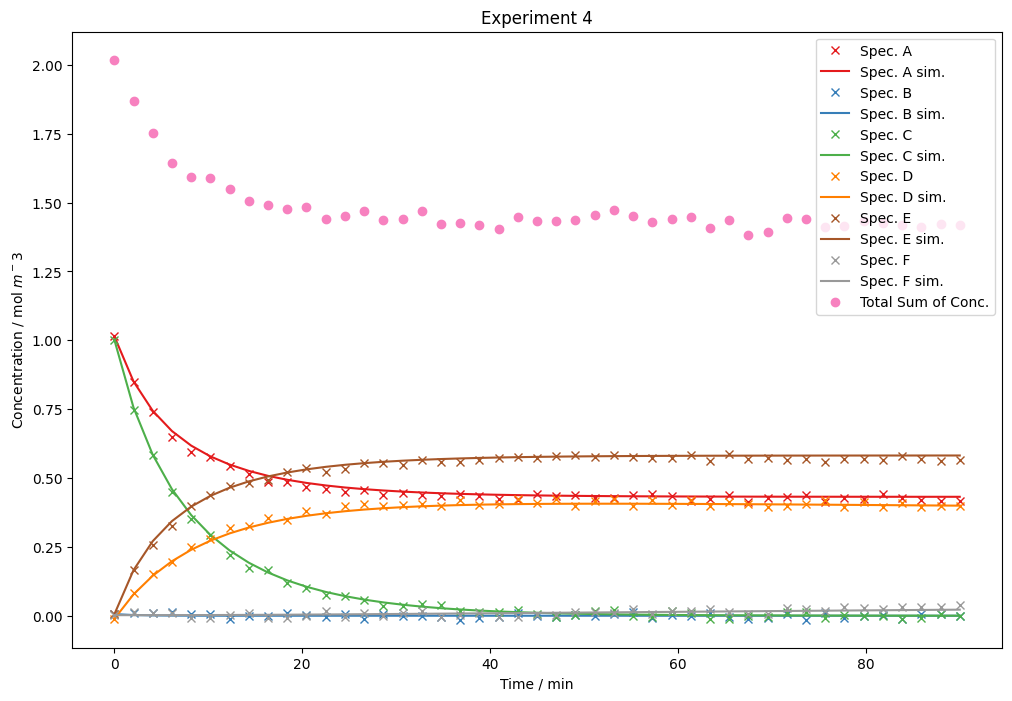

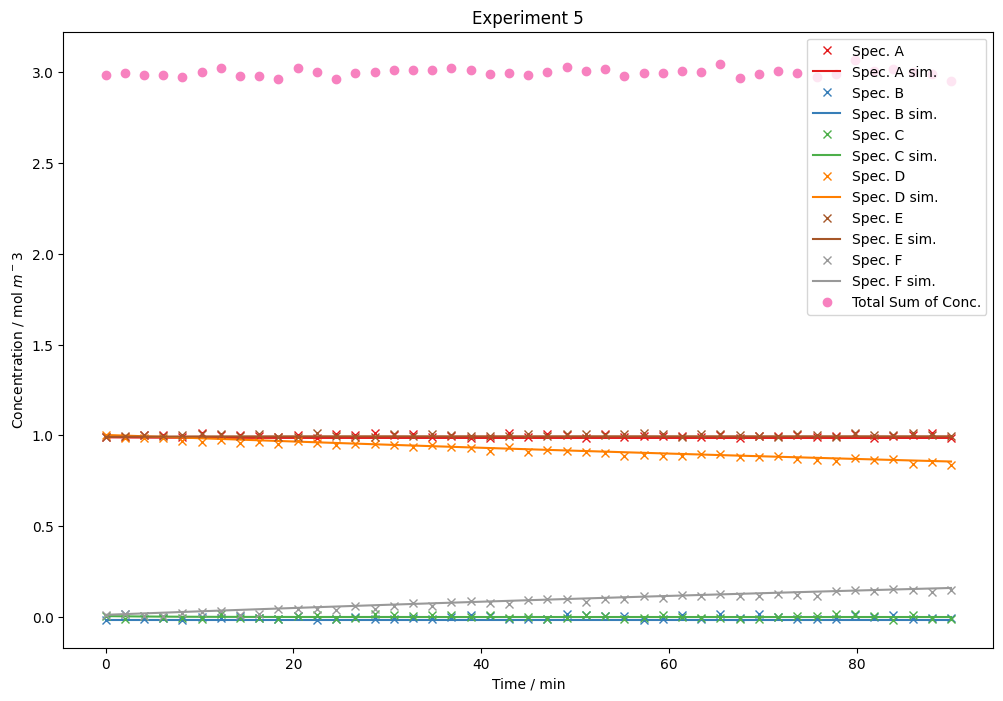

In [44]:
for i in range(no_of_exp):
    plt.subplots(figsize=(12,8))
    total_conc = np.zeros(45)
    for j in range(no_of_species):
        start = i * 270 + j *45                                         # starting point of each experimental series, 6 species times 45 measuring points equals 270 eperimental data points per experiment
        for p in range(45):
            total_conc[p] = total_conc[p] + ExperimentalData[start + p]
        plt.plot(exp_time[i], ExperimentalData[start : start + 45], 'x' , label = "Spec. " + speciescount[j], color = colors(colordivider[j]))
        plt.plot(exp_time[i], bestfit_res_with_n[i][j], label = "Spec. " + speciescount[j] + " sim.", color = colors(colordivider[j]))
        plt.title("Experiment " + str(i))
        plt.xlabel("Time / min")
        plt.ylabel("Concentration / mol $m^-3$")
    
    plt.plot(exp_time[i], total_conc, 'o', label = 'Total Sum of Conc.', color = colors(0.8))
    plt.legend()
    plt.show()

## Results from the second parameter estimation with reaction order n

| Parameter | Value | Standart deviation | Relative deviation |
|---|---|---|---|
| $k_0$ | 0.09706 | 0.001905$ | 1.96% |
| $k_1$ | 0.19394 | $0.00360$ | 1.86% |
| $k_2$ | 0.04995 | $3.44 \cdot 10^{-4}$ | 0.69% |
| $k_3$ | 0.00195 | $2.49 \cdot 10^{-5}$ | 1.28% |
| $n_0$ | 1.00715 | $0.01741$ | 1.73% |
| $n_1$ | 0.99399 | $0.02384$ | 2.40% |
| $n_2$ | 1.09887 | $0.01855$ | 1.69% |
| $n_3$ | 0.84738 | $0.00203$ | 0.24% |
| $n_4$ | 1.00724 | $0.00748$ | 0.74% |
| $n_5$ | 2.21342 | $0.08222$ | 3.71% |


| Error Metric | Value |
|---|---|
| $R^2$     | 0.9990 |
| RMSE      | 0.0113 |
| $\chi^2$  | 0.2050 |

The values of $k$ and $n$ obtained through the second fitting iteration are physically realistic. 
The values of $k_0$–$k_3$ did not change significantly from the first parameter fit, confirming 
that the first fit was already a good estimate. The relative deviation increased slightly compared 
to the first iteration. This is partly due to the smaller starting values for $k$, which increases 
the relative deviation, but also because more parameters are being varied, resulting in a solution 
space of considerably higher dimensionality due to the increased dimensionality introduced by 
adding $n$.

The results from the additional fitting of the reaction orders $n_0$–$n_5$ show an improvement 
across all statistical fit quality metrics. This demonstrates that the extended model improves 
the accuracy of the simulated data. Compared to the fit using only the kinetic constants, the 
improvement is modest. This is because the fit using only the kinetic constants was already very 
good, leaving little room for further improvement. This is also reflected in the small variation 
in the $k$ values relative to the first estimation.

# 9. Conclusion



# 9. Conclusion

In this assignment, we were given a set of experimental concentration–time data for 6 species 
A–F from 6 batch reactor experiments. Our task was to formulate a sound hypothesis for a 
possible reaction network and to validate it by fitting reaction parameters using mathematical 
methods.

## Summary of Methodology

Starting from the fundamental mass balance for a constant-volume, isothermal batch reactor, 
the system of coupled ordinary differential equations governing species concentrations reduces 
to $\frac{dc_i}{dt} = \sum_j \nu_{i,j} r_j$. By systematically analyzing the experimental 
concentration profiles — beginning with the simplest experiments and progressively 
cross-referencing across all six — we were able to deduce a four-reaction network involving 
consecutive and parallel reaction pathways. This hypothesis-driven approach mirrors standard 
practice in reaction engineering, where mechanistic insight and data analysis are combined 
iteratively to arrive at a plausible kinetic model [1].

For parameter estimation, we employed the `lmfit` minimizer with a sequential two-stage 
fitting strategy. In the first stage, the reaction rate constants $k$ were fitted with reaction 
orders fixed at $n = 1$. This is mathematically justified by the structure of the power-law 
rate expression $r = k c^n$: the model is linear in $k$, yielding a well-posed regression 
problem, whereas simultaneous fitting of $n$ introduces strong nonlinearity and a 
high-dimensional solution space prone to local minima and physically unrealistic results — 
as explicitly demonstrated in Section 8. In the second stage, the optimized $k$ values served 
as informed starting points for the joint estimation of both $k$ and $n$, significantly 
improving solver stability and convergence.

## Quality of Results

The fitted reaction network reproduces the experimental data with high fidelity. The obtained 
reaction orders $n_0$–$n_4$ cluster closely around 1, consistent with elementary reaction 
steps, which lends additional physical plausibility to the model. The notably higher value of 
$n_5 = 2.21$ for the D→F reaction suggests a more complex mechanistic dependency for this 
step, which could be a subject for further investigation. The error metrics confirm the quality 
of the fit:

| Error Metric | Value Iteration 1 | Value Iteration 2 |
|---|---|---|
| $R^2$     | 0.9987 | 0.9990 |
| RMSE      | 0.0129 | 0.0113 |
| $\chi^2$  | 0.2708 | 0.2050 |

The improvement from the first to the second iteration is modest, which is itself a meaningful 
result: it confirms that the initial estimate of $k$ alone already captured the dominant 
dynamics of the system, and that the reaction orders are close to unity. The residual 
deviation of approximately 0.0113 mol m$^{-3}$ can, to a significant extent, be attributed 
to inherent measurement uncertainty in the experimental data.

We therefore conclude that the reaction network

$$1A + 1C \rightarrow 1E \tag{0}$$
$$1A + 1B \rightarrow 1C \tag{1}$$
$$1C \rightarrow 1D \tag{2}$$
$$1D \rightarrow 1F \tag{3}$$

with the fitted parameters

| Parameter | Value |
|---|---|
| $k_0$ | 0.09706 | 
| $k_1$ | 0.19394 | 
| $k_2$ | 0.04995 | 
| $k_3$ | 0.00195 | 
| $n_0$ | 1.00715 | 
| $n_1$ | 0.99399 | 
| $n_2$ | 1.09887 | 
| $n_3$ | 0.84738 | 
| $n_4$ | 1.00724 | 
| $n_5$ | 2.21342 | 

provides a sound and physically realistic description of the reaction system in the batch reactor.

## Link to Industrial Application

The methodology developed in this report is directly transferable to industrial batch reactor 
processes, where knowledge of kinetic parameters is essential for process design, optimization, 
and scale-up.

A concrete and realistic scenario is the **pharmaceutical synthesis of an active pharmaceutical 
ingredient (API)** in a stirred batch reactor — one of the most common unit operations in the 
fine chemicals and pharmaceutical industry [4]. In such processes, a desired intermediate or 
final product is typically formed through a network of consecutive and parallel reactions, 
precisely as identified here. For example, the network identified in this report — in which 
species A and B react to form C, which subsequently reacts further to D and F, while a parallel 
pathway consumes C and A to form E — is structurally analogous to common multi-step synthesis 
routes, where reaction selectivity between a desired product and undesired byproducts must be 
carefully controlled.

In an industrial context, the kinetic parameters $k$ and $n$ fitted in this report would 
directly inform:

- **Reactor design**: The rate constants determine the required residence time and reactor 
  volume for a target conversion.
- **Yield optimization**: Knowing that reaction (0) ($A + C \rightarrow E$) competes with 
  reaction (2) ($C \rightarrow D$) for species C, a process engineer could adjust the initial 
  concentration ratio of A to B, or the feed strategy, to suppress byproduct E and maximize 
  the yield of D or F.
- **Process control**: The slow rate of reaction (3) ($D \rightarrow F$, $k_3 = 0.00195$) 
  suggests that the conversion of D to F is the rate-limiting step. In an industrial setting, 
  this would guide decisions on reactor temperature, residence time, or catalyst selection to 
  accelerate this bottleneck step.

As noted, the current model assumes isothermal conditions, which simplifies the parameter 
estimation considerably. In reality, industrial batch reactors often operate under 
non-isothermal conditions, and the rate constants $k$ exhibit a strong temperature dependence 
described by the Arrhenius equation $k(T) = A \, e^{-E_a / RT}$, where $E_a$ is the 
activation energy and $A$ the pre-exponential factor [1]. Extending the present model to 
incorporate temperature dependence — by fitting $E_a$ and $A$ from experiments at multiple 
temperatures — would be the most impactful next step, and would produce a model suitable for 
direct use in industrial process simulation and optimisation tools such as Aspen Plus or 
MATLAB's SimBiology.

# In Addition: Evaluating Reaction Order n Before Reaction Rate Constant k

As discussed in the introduction, it is considerably more appropriate to first vary the kinetic 
constant as a parameter, because it has a linear impact on the solution of the reaction network.

This is further illustrated if the solver is started with values of 1 for all reaction rate 
constants $k$ and $n$ is fitted instead (as shown below). This yields highly unrealistic values 
of $n$ for reactions 2 and 3, with reaction 3 exhibiting a deviation of 
±12882.3667 (257647.33%). This value is far outside any reasonable range and should therefore 
be disregarded as a meaningful result. The value of $\chi^2$ is 110.181909, indicating poor fit 
quality. The values of $R^2$ (0.48) and RMSE (0.26) are also considerably worse than those 
obtained when fitting only $k$.

This confirms that our approach of fitting $k$ first is the more appropriate choice.

In [45]:
def ode_with_only_n(t, c, n):
    """
    Calculate time derivatives of the ode for a batch STR
    Parameters
    ----------
    t: float
        time of the calculation;\\
    c: array
        concentration values at time t, size [nc]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    dcdt: array
        time derivatives of the concentration, size [nc]
    """

    c = np.maximum(c, 0) # to avoid negative concentrations, which can cause problems with the power function, we set all negative values to 0. This is reasonable, as negative concentrations are not physically meaningful.

    # calculating reaction rates
    r0 = 1 * c[0]**n[0] * c[2]**n[1]
    r1 = 1 * c[0]**n[2] * c[1]**n[3]
    r2 = 1 * c[2]**n[4]
    r3 = 1 * c[3]**n[5]

    #calculating the derivatives
    dcdt = np.zeros_like(c)         # initialises an array filled with zeros with the exact same shape as the array of given concentrations c
    dcdt[0] = - r0 -r1 
    dcdt[1] = - r1
    dcdt[2] = + r1 - r2 - r0
    dcdt[3] = + r2 - r3
    dcdt[4] = + r0
    dcdt[5] = + r3
    return dcdt

def solver_with_only_n(t, init_conc, n):
    """
    Simulate single experiment using solve_ivp.
    Parameters
    ----------
    t: array
       array with the time points of the simulation, size [nt]\\
    init_conc: array
        initial concentrations, size [nc]\\
    n: array
        reaction rates for alle species and all reactions, sizen [n_sp]

    Returns
    -------
    c_sol: array
        concentration values at times defined by t, size [nc, nt]
    """
    solution = scp.solve_ivp(fun=ode_with_only_n, t_span=[t[0],t[-1]], y0=init_conc, method = 'LSODA', t_eval=t, args=[n])
    return solution.y

def sim_multiple_exps_with_only_n(times, n0, n1, n2, n3, n4, n5, c_inits):
    """
    Simulate results for n experiments with nc components and 4 reactions. Each experiment has nt_i entries. 
    Note: This had to be modified from the example Code, because in this Case there are (presumably) 4 Reactions.

    Parameters
    ----------
    times: list
        List of arrays with times of sampling for each experiment, size [n][nt_i,]\\
    c_inits: list
        List of arrays with initial concentrations, size [n][nc]\\
    n0: float
        reaction rate of first species first reaction
    n1: float
        reaction rate of second species first reaction
    n2: float
        reaction rate of first species second reaction
    n3: float
        reaction rate of second species second reaction
    n4: float
        reaction rate of first species third reaction
    n5: float
        reaction rate of first species fourth reaction

    Returns
    -------
    sim concs: list
        List of arrays with calculated concentration values, size[n][nc, nt_i].
    """

    sim_concs = []
    n = [n0, n1, n2, n3, n4, n5]

    # iterate over all experiments
    nex = len(times)
    for i in np.arange(0, nex):
        # assign c and t to run simulation
        c_0 = c_inits[i]
        t = times[i]

        # run simulation for one experiment
        conc = solver_with_only_n(t, c_0, n)
        sim_concs.append(conc)
    return sim_concs

def estimator_with_only_n(params, t, initial_concs, actual_data):
    """
    Minimizes the Difference between simulated Data and given experimental Data through iteration, changing the parameters to fit every Iteration

    Parameters
    -----------
    params:
        the parameters we want to change and fit through iteration\\
    t:
        Measurements times of the experiments, in the Format of a List of arrays\\
    actual_data:
        actual Data from the experiments, List of arrays \\
    initial_concs:
        initial concentrations of each experiment, List of arrays\\

    Returns
    ----------
    diff:
        difference between simulated result and actual Data
    """

    sim_res = sim_multiple_exps_with_only_n(t,  params["n0"], params["n1"], params["n2"], params["n3"], params["n4"], params["n5"], initial_concs) # returns a List of arrayss, with the Results for experiment 0-5
    flat_sim_res = np.array([]) # empty array to store simulated Data in for comparison with experimental Data
    nex = len(t)
    for i in np.arange(0,nex):
        flat_sim_res = np.append(flat_sim_res, sim_res[i])

    return flat_sim_res - actual_data


params_with_only_n = lmfit.Parameters()
params_with_only_n.add('n0', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n1', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n2', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n3', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n4', value = 1, min = 0, max = 5, vary = True)
params_with_only_n.add('n5', value = 1, min = 0, max = 5, vary = True)
minimized_res_with_only_n = lmfit.Minimizer(estimator_with_only_n, params_with_only_n, fcn_args=(exp_time, init_c_val, ExperimentalData))
result_with_only_n = minimized_res_with_only_n.minimize()
lmfit.report_fit(result_with_only_n)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 1639
    # data points      = 1620
    # variables        = 6
    chi-square         = 110.181909
    reduced chi-square = 0.06826636
    Akaike info crit   = -4342.63891
    Bayesian info crit = -4310.29782
[[Variables]]
    n0:  0.98955333 +/- 0.33368633 (33.72%) (init = 1)
    n1:  3.42522934 +/- 0.27606216 (8.06%) (init = 1)
    n2:  0.38329421 +/- 1.34863721 (351.85%) (init = 1)
    n3:  3.25216856 +/- 2.22407682 (68.39%) (init = 1)
    n4:  4.99622001 +/- 0.00955693 (0.19%) (init = 1)
    n5:  5.00000000 +/- 12882.3667 (257647.33%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(n2, n3) = -0.9840
    C(n0, n4) = +0.8866
    C(n0, n1) = -0.7818
    C(n1, n4) = -0.4082
    C(n2, n4) = +0.2685
    C(n0, n2) = +0.2613
    C(n3, n4) = -0.1691
    C(n0, n3) = -0.1672
    C(n1, n2) = -0.1450


In [58]:
bestfit_res_with_only_n = sim_multiple_exps_with_only_n(exp_time, result_with_only_n.params["n0"], result_with_only_n.params["n1"], result_with_only_n.params["n2"], result_with_only_n.params["n3"], result_with_only_n.params["n4"], result_with_only_n.params["n5"], init_c_val)
print(R2_total(bestfit_res_with_only_n, ExperimentalData))
print(R2_for_each_exp(exp_conc, bestfit_res_with_only_n))

0.48062
['Experiment 0, Species A: 0.88834' 'Experiment 0, Species B: 0.8905'
 'Experiment 0, Species C: -1.73745' 'Experiment 0, Species D: -0.45306'
 'Experiment 0, Species E: 0.84017' 'Experiment 0, Species F: -5.83601'
 'Experiment 1, Species A: -0.01354' 'Experiment 1, Species B: -2.20341'
 'Experiment 1, Species C: 0.49865' 'Experiment 1, Species D: -3.22738'
 'Experiment 1, Species E: -2.66373' 'Experiment 1, Species F: -86.54131'
 'Experiment 2, Species A: -2.36902' 'Experiment 2, Species B: -2.71272'
 'Experiment 2, Species C: -0.52702' 'Experiment 2, Species D: -158.51527'
 'Experiment 2, Species E: -0.00544' 'Experiment 2, Species F: -183.32379'
 'Experiment 3, Species A: -1.27531' 'Experiment 3, Species B: -0.00307'
 'Experiment 3, Species C: 0.49258' 'Experiment 3, Species D: -3.30875'
 'Experiment 3, Species E: -0.10139' 'Experiment 3, Species F: -97.06498'
 'Experiment 4, Species A: 0.87008' 'Experiment 4, Species B: -0.55636'
 'Experiment 4, Species C: 0.51005' 'Experim

In [59]:
print(RMSE_total(bestfit_res_with_only_n, ExperimentalData))
print(RMSE(exp_conc, bestfit_res_with_only_n))

0.26079
['Experiment 0, Species A: 0.06515' 'Experiment 0, Species B: 0.0491'
 'Experiment 0, Species C: 0.18438' 'Experiment 0, Species D: 0.19953'
 'Experiment 0, Species E: 0.01856' 'Experiment 0, Species F: 0.03786'
 'Experiment 1, Species A: 0.00817' 'Experiment 1, Species B: 0.01613'
 'Experiment 1, Species C: 0.18579' 'Experiment 1, Species D: 0.48726'
 'Experiment 1, Species E: 0.01834' 'Experiment 1, Species F: 0.34261'
 'Experiment 2, Species A: 0.01724' 'Experiment 2, Species B: 0.01509'
 'Experiment 2, Species C: 0.01012' 'Experiment 2, Species D: 0.61711'
 'Experiment 2, Species E: 0.00787' 'Experiment 2, Species F: 0.61525'
 'Experiment 3, Species A: 0.01379' 'Experiment 3, Species B: 0.00783'
 'Experiment 3, Species C: 0.18709' 'Experiment 3, Species D: 0.48453'
 'Experiment 3, Species E: 0.00966' 'Experiment 3, Species F: 0.35091'
 'Experiment 4, Species A: 0.04256' 'Experiment 4, Species B: 0.00962'
 'Experiment 4, Species C: 0.14697' 'Experiment 4, Species D: 0.15909'

# References

[1] Levenspiel, Chemical Reaction Engineering, Wiley, 1999

[2] Gasparyan, M.; Rao, S. Parameter Estimation for Kinetic Models of 
    Chemical Reaction Networks from Partial Experimental Data of Species' 
    Concentrations. Bioengineering 2023, 10, 1056. https://pmc.ncbi.nlm.nih.gov/articles/PMC10526083/

[3] Model-based evaluation and data requirements for parallel kinetic experimentation and data-
driven reaction identification and optimization
https://pubs.rsc.org/en/content/articlehtml/2023/dd/d3dd00016h

[4] Formigosa, L. F., dos Santos, I. C., Alves e Álvares, L. E., Macêdo, E. N., Gonçalves, L. R. B., & Viegas, B. M. (2025). Mathematical modeling of amoxicillin synthesis in batch and semi-batch reactor: Application of Bayesian statistics and genetic algorithm. Biotechnology and Bioengineering, 123(1), 104–115. https://doi.org/10.1002/bit.70096

# AI Declaration

In this Assignment, we used ClaudeAI (Haiku 4.5, May 2025) for brainstorming and code drafting. Also, we used the github copilot (May 2025) autocompletion in the jupyter Notebook, to accelerate Work with coding. We did not use Copilot to generate Code in the Notebook. We also used Claude for grammar and style corrrection for the written report and literature research. The Links for the Chats with Claude are pasted below.

Brainstorming and coding help: https://claude.ai/share/59866cb7-70f0-4885-ae23-82c6a87ccf0a

Grammar correction: https://claude.ai/share/815c9163-17c1-4f86-8e5e-b4003db7bb3c

Note: there was also prompting in a chat that wasnt purely for the assignment(mixup during work), so we cannot share the whole chat. But the prompts were as follows:

"Bitte gib mir Beispiele für eine industrielle Anwendung der Methode der Parameter-Estimation für ein unbekanntes Reaktionsnetzwerk. "

"Bitte überprüfe, ob die Implementierung wie folgt in meiner Conclusion sinnvoll und korrekt getippt ist. Suche außerdem wissenschaftliche Quellen um die Aussagen zu stützen. Korrigierten Text bitte als Jupyter-Notebook markdown. "pasted Text" "